---
# Logistic Regression — Philippine Employee Stagnation

We are trying to predict whether a Filipino worker is considered stagnant (`is_stagnant = 1`) or not (`is_stagnant = 0`) using Binary Logistic Regression. The processed dataset was produced by the data pipeline notebook and contains 2.7 million employed working-age respondents from the Philippine Statistics Authority's Labour Force Survey covering 2021 to 2024.<br><br>

Since our target variable has two possible outcomes (stagnant or not stagnant), Binary Logistic Regression is appropriate. Instead of predicting a continuous value like in linear regression, logistic regression predicts the probability that a record belongs to one of the two classes.<br><br>

---

Import `pandas` with placeholder `pd` to make use of DataFrames to hold values for our variables.

In [11]:
import pandas as pd

Import `numpy` with placeholder `np` since our variables are stored as arrays.

In [12]:
import numpy as np

Import `os` to handle file paths across different operating systems.

In [13]:
import os

Import `matplotlib` with placeholder `plt` to plot datapoints and visualize our results.

In [14]:
import matplotlib.pyplot as plt

Import `seaborn` with placeholder `sns` for visualization. In this case it is used mainly for the confusion matrix.

In [15]:
import seaborn as sns

Import `LogisticRegression` from the `linear_model` module in `scikit-learn`. We are importing a prebuilt logistic regression algorithm. It is in `linear_model` since the relationship between features and the log-odds is linear, and the Sigmoid function is what makes the output non-linear.

In [16]:
from sklearn.linear_model import LogisticRegression

Import `StandardScaler` from the `preprocessing` module in `scikit-learn` to standardize our features. This is needed since our features differ in scale — `age` has much larger values than binary columns like `sex`. Features with larger values might otherwise dominate the model.

In [17]:
from sklearn.preprocessing import StandardScaler

Import `classification_report`, `confusion_matrix`, `precision_recall_curve`, and `average_precision_score` from the `metrics` module in `scikit-learn` to evaluate our model.

In [18]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
)

# --- Step 1: LOAD DATA ---

This reads and stores our processed dataset into a dataframe. The file was saved by the data pipeline notebook. It contains all employed working-age respondents with engineered features and the `is_stagnant` target variable already constructed.

In [19]:
# --- Step 1: LOAD DATA ---

BASE = os.path.join(os.path.dirname(os.getcwd()), 'ph-lfs-stagnation')
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.path.dirname(os.getcwd())
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.getcwd()

DATA_DIR = os.path.join(BASE, 'data')

df = pd.read_csv(os.path.join(DATA_DIR, 'employed_processed.csv'), low_memory=False)
print('file loaded!')
print(f'Shape: {df.shape}')

file loaded!
Shape: (2740496, 22)


# --- Step 2: SELECT FEATURES ---

We define which columns will be used as predictors (`FEATURE_COLS`) and which is the target (`is_stagnant`). Several columns are excluded entirely to prevent data leakage. The stagnation rule draws on six inputs — `want_more_work`, `nature_employment`, `worker_class`, `education_grade`, `occupation_code`, and the derived columns `education_level` and `occupation_major` — all of which the data pipeline drops before saving the processed file. Including any of them would let the model re-derive the rule it was trained against.<br><br>

The remaining columns such as raw admin fields and survey IDs are also excluded since they add noise or carry no predictive signal.

In [20]:
# --- Step 2: SELECT FEATURES ---

FEATURE_COLS = [
    'age',
    'sex',
    'marital_status',
    'region',
    'urban_rural',
    'hh_size',
    'industry_sector',
    'normal_hours',
    'actual_hours',
    'month_sin',
    'month_cos',
    'gdp_per_employed',
]

TARGET_COL = 'is_stagnant'

model_df = df[FEATURE_COLS + [TARGET_COL, 'survey_year']].copy()
print(f'Features: {len(FEATURE_COLS)}')
print(f'Total rows: {len(model_df):,}')
print(f'Stagnation rate: {model_df[TARGET_COL].mean()*100:.1f}%')

Features: 12
Total rows: 2,740,496
Stagnation rate: 8.1%


# --- Step 3: PEARSON CORRELATION ---

Before training the model, we check how each feature is linearly correlated with the target variable using Pearson correlation. A positive value means the feature tends to increase when `is_stagnant` is 1, and a negative value means it tends to decrease. Features with values closer to 0 have little linear relationship with the target.<br><br>

This helps us understand which features might be most useful and gives us a baseline for interpreting the model coefficients later.

Pearson correlation with is_stagnant:
actual_hours       -0.1860
normal_hours       -0.1048
industry_sector    -0.0824
age                -0.0817
marital_status     -0.0462
month_cos          -0.0171
sex                -0.0147
gdp_per_employed   -0.0132
month_sin          -0.0081
region              0.0028
hh_size             0.0335
urban_rural         0.0735


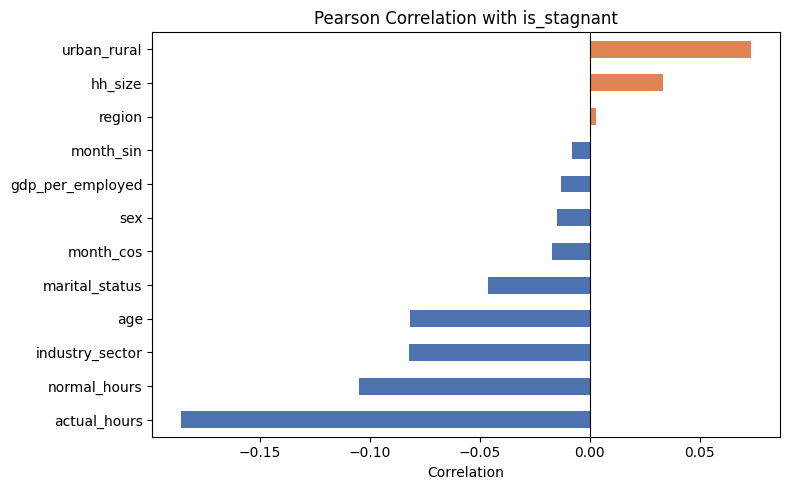

In [21]:
# --- Step 3: PEARSON CORRELATION ---

corr = model_df[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values()

print('Pearson correlation with is_stagnant:')
print(corr.round(4).to_string())

plt.figure(figsize=(8, 5))
corr.plot(kind='barh', color=['#DD8452' if v > 0 else '#4C72B0' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation with is_stagnant')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# --- Step 4: TRAIN/TEST SPLIT ---

We split the data by year instead of using a random split. Workers from 2021 to 2023 are used for training, and 2024 workers are used for testing. This is more realistic since we are simulating a situation where the model is trained on past data and then used to predict stagnation in a future period.<br><br>

*Note: A random split would mix 2024 records into the training set which could inflate performance since the model would have seen data from the same period it is being tested on.*

In [22]:
# --- Step 4: TRAIN/TEST SPLIT ---

# Train on 2021-2023, test on 2024
train_df = model_df[model_df['survey_year'] < 2024]
test_df  = model_df[model_df['survey_year'] == 2024]

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET_COL].copy()

print(f'Train: {len(X_train):,} rows   Test: {len(X_test):,} rows')
print(f'Train stagnation rate: {y_train.mean()*100:.2f}%')
print(f'Test  stagnation rate: {y_test.mean()*100:.2f}%')

Train: 2,060,789 rows   Test: 679,707 rows
Train stagnation rate: 8.45%
Test  stagnation rate: 6.95%


# --- Step 5: IMPUTATION ---

Some features have missing values. We fill these before training so the model has complete data. The fill values are calculated from the training set only to avoid leaking information from the test set.<br><br>

- `urban_rural` is missing for all 2024 respondents since PSA removed this column from that year's survey. We fill it with the most common value (mode) from the training set.
- `region` has some missing values and is also filled with the training mode.
- Continuous columns like `normal_hours` and `actual_hours` are filled with the training median.

In [23]:
# --- Step 5: IMPUTATION ---

MODE_COLS   = ['urban_rural', 'region', 'marital_status', 'industry_sector', 'sex']
MEDIAN_COLS = ['age', 'hh_size', 'normal_hours', 'actual_hours',
               'month_sin', 'month_cos', 'gdp_per_employed']

fill_values = {}
for col in MODE_COLS:
    mode_val = X_train[col].mode(dropna=True)
    fill_values[col] = int(mode_val.iloc[0]) if len(mode_val) > 0 else 0

for col in MEDIAN_COLS:
    fill_values[col] = float(X_train[col].median())

X_train = X_train.fillna(fill_values)
X_test  = X_test.fillna(fill_values)

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print('Nulls after imputation (train):', X_train.isnull().sum().sum())
print('Nulls after imputation (test) :', X_test.isnull().sum().sum())

Nulls after imputation (train): 0
Nulls after imputation (test) : 0


# --- Step 6: FEATURE SCALING ---

This standardizes all features to have a mean of 0 and a standard deviation of 1. We do this because our features differ in scale. Without scaling, features with larger values can produce unfair coefficients and might dominate the model.<br><br>

We fit the scaler on the training set only and apply it to both sets. Fitting on both sets would let the scaler see the test data distribution, which is a form of leakage.

In [24]:
# --- Step 6: FEATURE SCALING ---

# Fit on training set only, then apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Step 7: TRAIN THE MODEL ---

This creates an instance of the logistic regression model.<br><br>

The `C` parameter controls regularization. A smaller value means stronger regularization, which prevents any single predictor from dominating the log-odds. We use the default `C=1.0` since the features are already standardized.<br><br>

The `solver='saga'` is an optimization algorithm that works well for large datasets. We cannot use `liblinear` here since our dataset has over 2 million rows and `liblinear` is designed for smaller datasets.<br><br>

Since our target variable is imbalanced (only about 8% of workers are stagnant), we added `class_weight='balanced'`. This gives the minority class (stagnant = 1) more importance during training so the model does not just learn to always predict 0.<br><br>

*Note: Our training set contains 174,176 stagnant workers versus 1,886,613 non-stagnant workers. Without `class_weight='balanced'`, the model would be biased toward predicting not stagnant.*

In [25]:
# --- Step 7: TRAIN THE MODEL ---
model = LogisticRegression(
    C=1.0,                      # Default regularization strength
    class_weight='balanced',    # Give more weight to the stagnant class
    solver='saga',              # Works well for large datasets
    max_iter=500,               # Maximum iterations for convergence
    random_state=42,
    n_jobs=-1,                  # Use all available CPU cores
)

model.fit(X_train_scaled, y_train)
print('Model trained.')

# Print coefficients to see which features have the strongest effect
coef_df = pd.DataFrame({'feature': FEATURE_COLS, 'coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('coefficient', ascending=False)
print('\nModel coefficients:')
print(coef_df.to_string(index=False))

c:\Users\clyde\Desktop\ph-lfs-stagnation\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model trained.

Model coefficients:
         feature  coefficient
    normal_hours     0.225368
     urban_rural     0.101478
         hh_size     0.052845
gdp_per_employed    -0.000341
             sex    -0.001685
  marital_status    -0.001960
          region    -0.009250
       month_sin    -0.044654
       month_cos    -0.085586
 industry_sector    -0.236379
             age    -0.330885
    actual_hours    -0.865676


# --- Step 8: CLASSIFICATION REPORT & CONFUSION MATRIX ---

This stores the class predictions made by the model and then compares them with the actual labels in `y_test` to evaluate model performance.

In [26]:
predictions = model.predict(X_test_scaled)

This prints precision, recall, and f1-score for each class. Precision measures how many of the predicted positives were actually positive. Recall measures how many of the actual positives were correctly identified. F1-score balances both using the harmonic mean.

In [27]:
print('Classification Report:')
print(classification_report(y_test, predictions,
                            target_names=['Not Stagnant (0)', 'Stagnant (1)']))

Classification Report:
                  precision    recall  f1-score   support

Not Stagnant (0)       0.96      0.73      0.83    632489
    Stagnant (1)       0.15      0.64      0.24     47218

        accuracy                           0.72    679707
       macro avg       0.56      0.68      0.54    679707
    weighted avg       0.91      0.72      0.79    679707



This prints the confusion matrix that visualizes the model predictions. It shows how many workers were correctly or incorrectly classified. True positives and true negatives are correct predictions, while false positives and false negatives are mistakes.

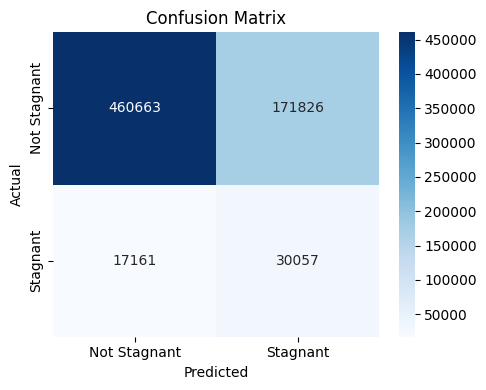

In [28]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Stagnant', 'Stagnant'],
            yticklabels=['Not Stagnant', 'Stagnant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Step 9: AUC-PR ---

We use AUC-PR (Area Under the Precision-Recall Curve) as our main evaluation metric instead of accuracy or AUC-ROC. This is because our dataset is heavily imbalanced — only about 7-8% of workers are labeled as stagnant. With this kind of imbalance, a model that just predicts not stagnant for everyone would achieve over 90% accuracy without learning anything useful.<br><br>

AUC-PR focuses on how well the model identifies the minority class (stagnant workers) across all possible probability thresholds. A higher AUC-PR means the model is better at ranking stagnant workers above non-stagnant workers in terms of predicted probability.<br><br>

The random baseline for AUC-PR is equal to the proportion of positive cases in the test set, which is around 0.07. Any score above this means the model is performing better than random guessing on the stagnant class.<br><br>

*Note: This is different from AUC-ROC which uses true positive rate and false positive rate. AUC-ROC can still appear high even when a model performs poorly on the minority class because it benefits from the large number of true negatives.*

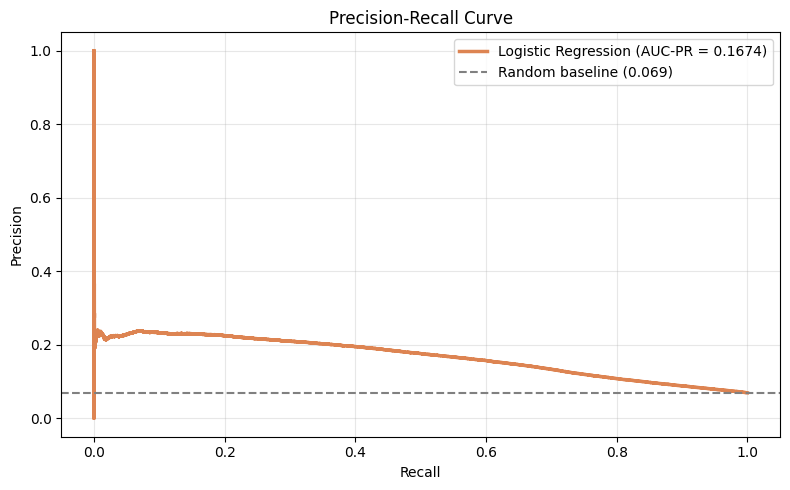

AUC-PR (Average Precision): 0.1674
Random baseline           : 0.0695


In [29]:
# --- Step 9: AUC-PR ---

# Get predicted probabilities for the positive class (stagnant = 1)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

# Average precision score is the area under the precision-recall curve
ap_score = average_precision_score(y_test, probabilities)

# Get precision and recall values across all thresholds
precision_vals, recall_vals, _ = precision_recall_curve(y_test, probabilities)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='#DD8452', linewidth=2.5,
         label=f'Logistic Regression (AUC-PR = {ap_score:.4f})')
plt.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1.5,
            label=f'Random baseline ({y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC-PR (Average Precision): {ap_score:.4f}')
print(f'Random baseline           : {y_test.mean():.4f}')